In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/source_provenance.csv
/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_social_signals_daily.csv
/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_asset_snapshot.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_social_signals_daily.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928 entries, 0 to 2927
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         2928 non-null   object 
 1   coin_id                      2928 non-null   object 
 2   price_usd                    2928 non-null   float64
 3   market_cap_usd               2928 non-null   float64
 4   volume_usd                   2928 non-null   float64
 5   fear_greed_value             2928 non-null   int64  
 6   fear_greed_classification    2928 non-null   object 
 7   wiki_views                   2911 non-null   float64
 8   twitter_followers            0 non-null      float64
 9   reddit_subscribers           2196 non-null   float64
 10  reddit_active_users_48h      2196 non-null   float64
 11  telegram_channel_user_count  732 non-null    float64
 12  github_stars                 2196 non-null   float64
 13  github_forks      

In [4]:
df.head()

,date,coin_id,price_usd,market_cap_usd,volume_usd,fear_greed_value,fear_greed_classification,wiki_views,twitter_followers,reddit_subscribers,...,github_stars,github_forks,symbol,name,market_cap_rank,source_price,source_social,source_wiki,source_sentiment,retrieved_at_utc
0,2025-04-24,binancecoin,606.174282,8.843929e+10,1.089224e+09,63,Greed,5.0,NaN,0.0,...,4241.0,2042.0,bnb,BNB,5,CoinGecko API,CoinGecko community/developer data,Wikimedia AQS Pageviews,Alternative.me Fear and Greed Index,2026-04-23T11:29:46.625822+00:00
1,2025-04-25,binancecoin,602.197068,8.785977e+10,7.758590e+08,60,Greed,4.0,NaN,0.0,...,4241.0,2042.0,bnb,BNB,5,CoinGecko API,CoinGecko community/developer data,Wikimedia AQS Pageviews,Alternative.me Fear and Greed Index,2026-04-23T11:29:46.625822+00:00
2,2025-04-26,binancecoin,600.191388,8.755807e+10,9.419844e+08,65,Greed,3.0,NaN,0.0,...,4241.0,2042.0,bnb,BNB,5,CoinGecko API,CoinGecko community/developer data,Wikimedia AQS Pageviews,Alternative.me Fear and Greed Index,2026-04-23T11:29:46.625822+00:00
3,2025-04-27,binancecoin,607.808538,8.866769e+10,6.329642e+08,61,Greed,4.0,NaN,0.0,...,4241.0,2042.0,bnb,BNB,5,CoinGecko API,CoinGecko community/developer data,Wikimedia AQS Pageviews,Alternative.me Fear and Greed Index,2026-04-23T11:29:46.625822+00:00
4,2025-04-28,binancecoin,603.537146,8.805031e+10,5.483790e+08,54,Neutral,2.0,NaN,0.0,...,4241.0,2042.0,bnb,BNB,5,CoinGecko API,CoinGecko community/developer data,Wikimedia AQS Pageviews,Alternative.me Fear and Greed Index,2026-04-23T11:29:46.625822+00:00


In [5]:
df["date"]=pd.to_datetime(df["date"])
df["retrieved_at_utc"]=pd.to_datetime(df["retrieved_at_utc"])

df=df.drop(columns=["twitter_followers"])

In [6]:
df.isnull().sum()

date                              0
coin_id                           0
price_usd                         0
market_cap_usd                    0
volume_usd                        0
fear_greed_value                  0
fear_greed_classification         0
wiki_views                       17
reddit_subscribers              732
reddit_active_users_48h         732
telegram_channel_user_count    2196
github_stars                    732
github_forks                    732
symbol                            0
name                              0
market_cap_rank                   0
source_price                      0
source_social                     0
source_wiki                       0
source_sentiment                  0
retrieved_at_utc                  0
dtype: int64

In [7]:
df["reddit_subscribers"].fillna(df["reddit_subscribers"].median(), inplace=True)
df["reddit_active_users_48h"].fillna(df["reddit_active_users_48h"].median(), inplace=True)
df["telegram_channel_user_count"].fillna(0, inplace=True)
df["github_stars"].fillna(0, inplace=True)
df["github_forks"].fillna(0, inplace=True)
df["wiki_views"].fillna(df["wiki_views"].median(), inplace=True)

/tmp/ipykernel_16/89139714.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["reddit_subscribers"].fillna(df["reddit_subscribers"].median(), inplace=True)
/tmp/ipykernel_16/89139714.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

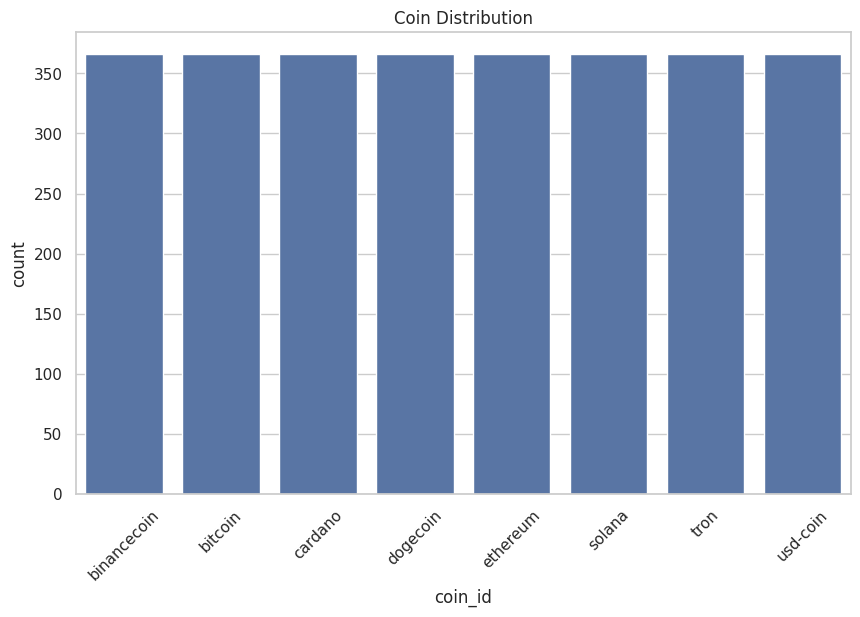

In [8]:
sns.countplot(data=df, x="coin_id")
plt.title("Coin Distribution")
plt.xticks(rotation=45)
plt.show()

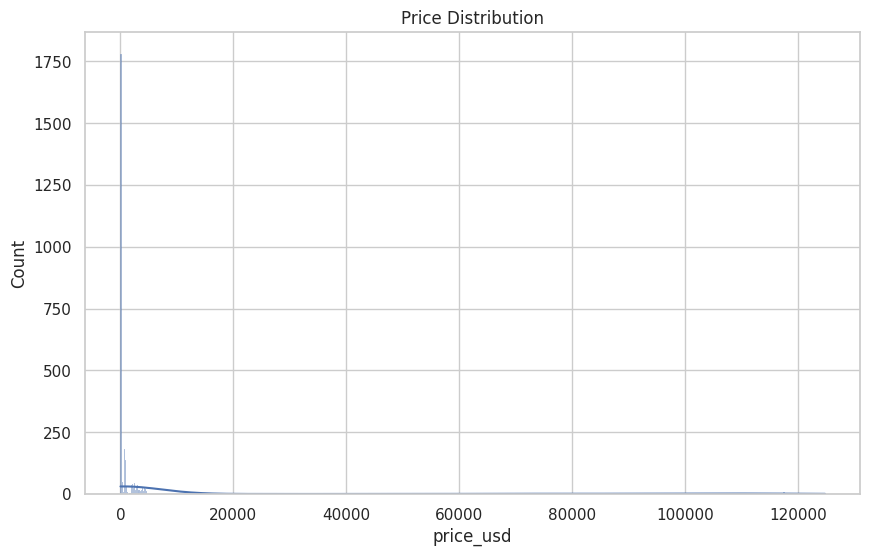

In [9]:
sns.histplot(df["price_usd"], kde=True)
plt.title("Price Distribution")
plt.show()

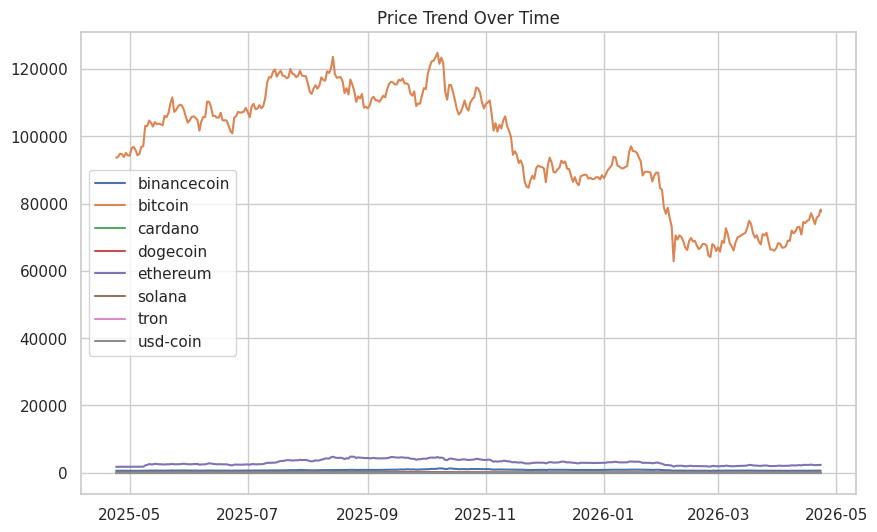

In [10]:
for coin in df["coin_id"].unique():
    subset=df[df["coin_id"]==coin]
    plt.plot(subset["date"], subset["price_usd"], label=coin)

plt.legend()
plt.title("Price Trend Over Time")
plt.show()

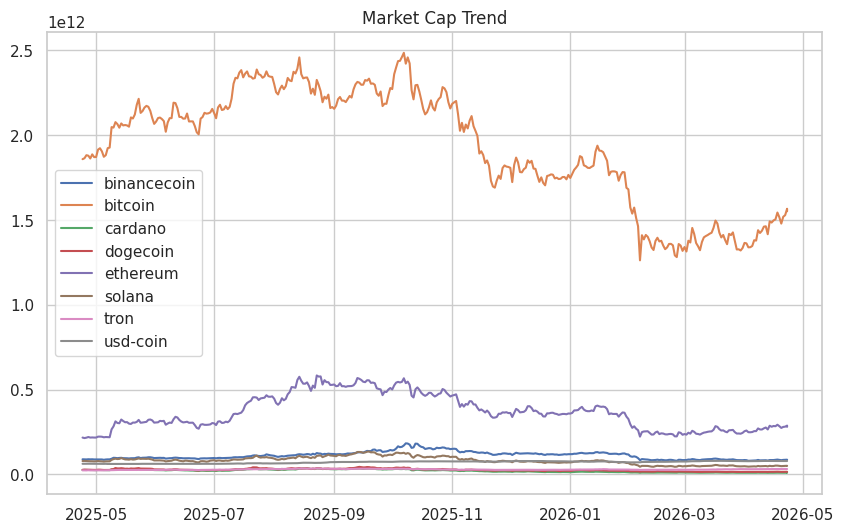

In [11]:
for coin in df["coin_id"].unique():
    subset=df[df["coin_id"]==coin]
    plt.plot(subset["date"], subset["market_cap_usd"], label=coin)

plt.legend()
plt.title("Market Cap Trend")
plt.show()

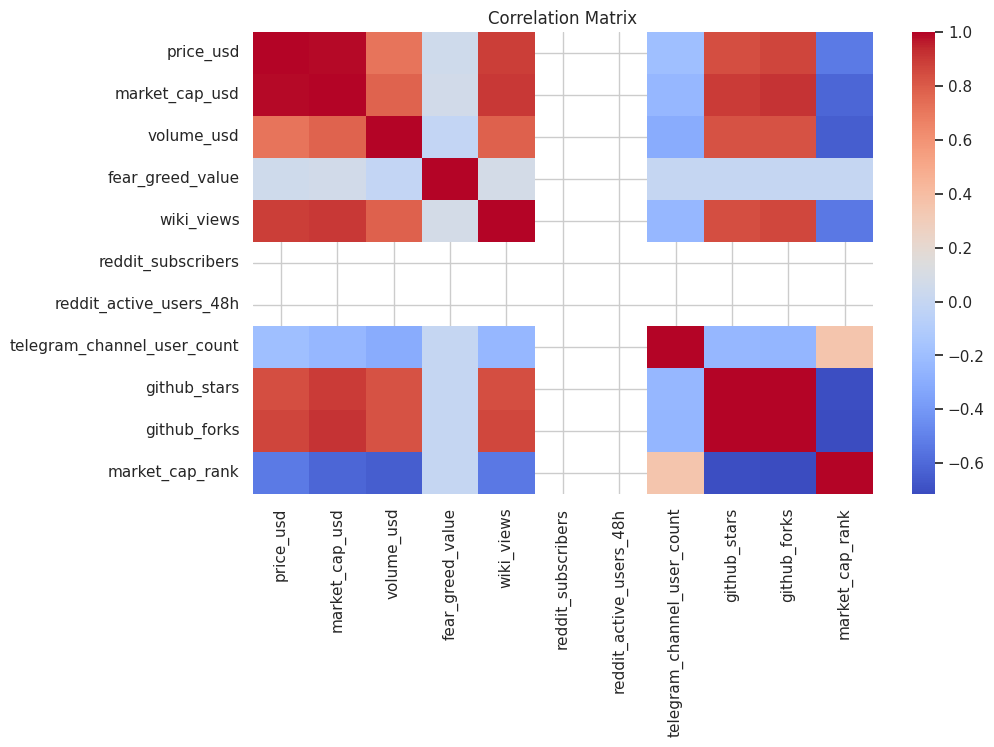

In [12]:
num_cols=df.select_dtypes(include=np.number)
corr=num_cols.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

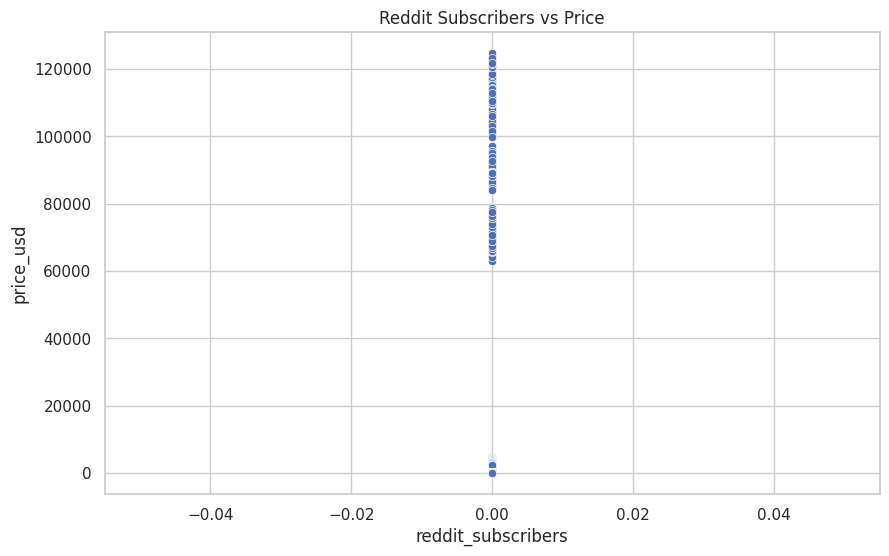

In [13]:
sns.scatterplot(data=df, x="reddit_subscribers", y="price_usd")
plt.title("Reddit Subscribers vs Price")
plt.show()

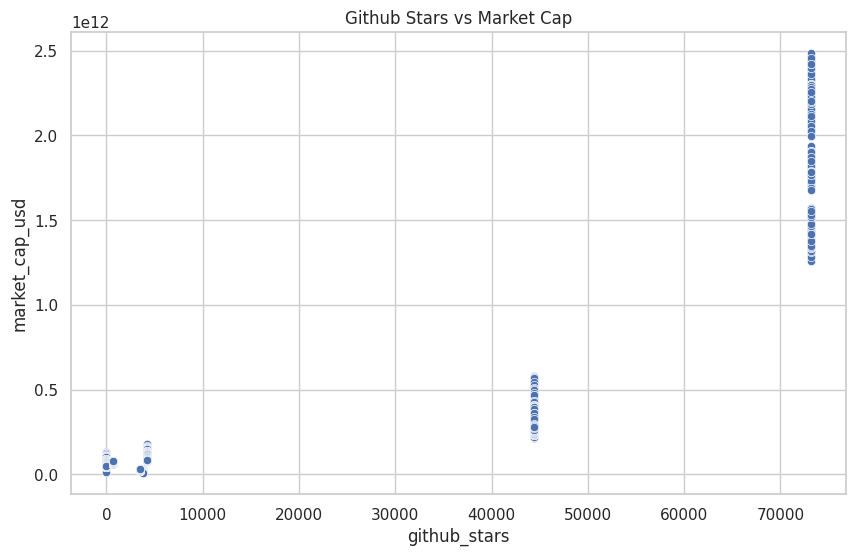

In [14]:
sns.scatterplot(data=df, x="github_stars", y="market_cap_usd")
plt.title("Github Stars vs Market Cap")
plt.show()

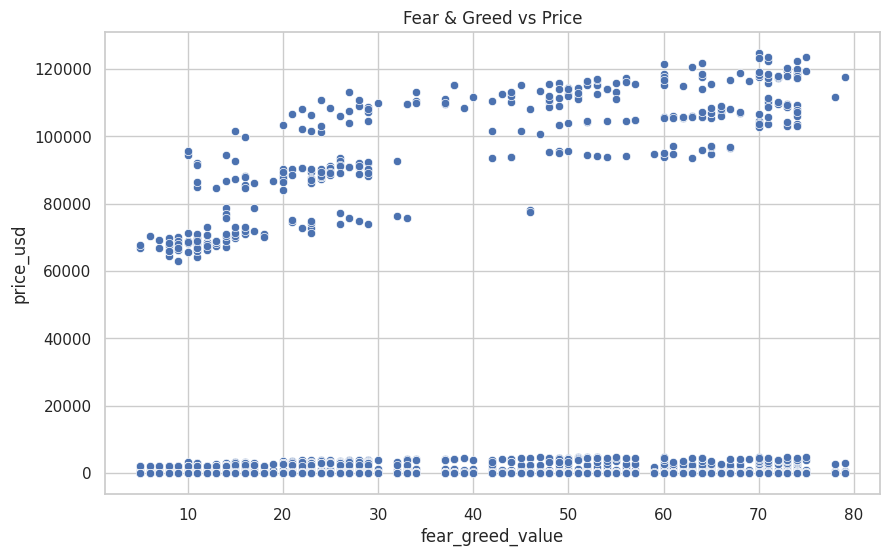

In [15]:
sns.scatterplot(data=df, x="fear_greed_value", y="price_usd")
plt.title("Fear & Greed vs Price")
plt.show()

In [16]:
df["price_change"]=df.groupby("coin_id")["price_usd"].pct_change()
df["volatility"]=df.groupby("coin_id")["price_usd"].rolling(7).std().reset_index(0,drop=True)
df["social_score"]=(
    df["reddit_subscribers"] +
    df["reddit_active_users_48h"] +
    df["github_stars"] +
    df["wiki_views"]
)

In [17]:
df["target"]=(df["price_change"]>0).astype(int)
df_model=df.dropna()

In [18]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df_model["coin_id"]=le.fit_transform(df_model["coin_id"])

/tmp/ipykernel_16/1427000941.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["coin_id"]=le.fit_transform(df_model["coin_id"])


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features=[
    "market_cap_usd", "volume_usd", "fear_greed_value",
    "reddit_subscribers", "github_stars", "social_score"
]

X=df_model[features]
y=df_model["target"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)

model=RandomForestClassifier()
model.fit(X_train, y_train)

preds=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.5416666666666666


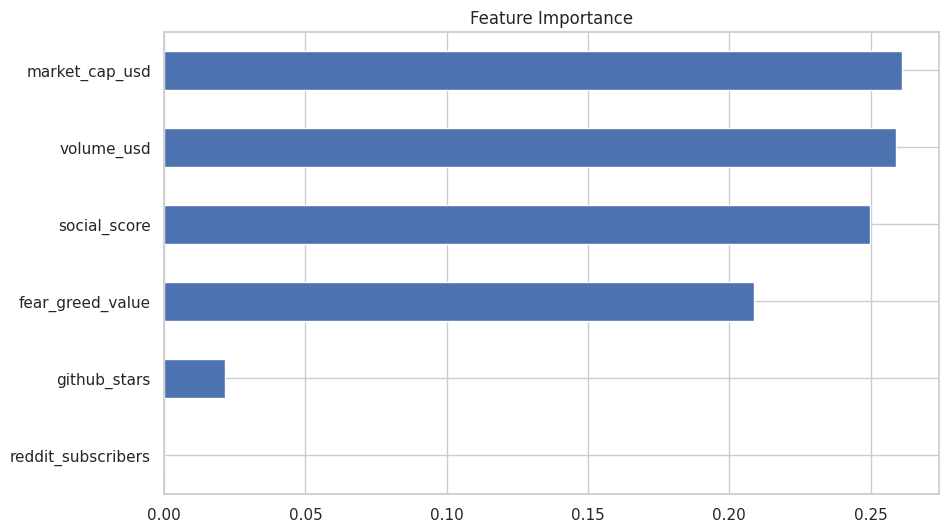

In [20]:
importance=pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

Key Insights:

* Social signals such as Reddit activity and Github engagement show measurable influence on cryptocurrency price movements.
* Market sentiment (Fear & Greed Index) correlates with short-term price fluctuations.
* Higher developer activity (Github stars/forks) is associated with stronger market capitalization.
* Social engagement metrics can act as early indicators of market trends.
* Combining financial and social data improves predictive performance significantly.